# 04 · Pipeline de Mensageria — Backtest v2 + Estado Atual

**Objetivo:** combinar saídas dos notebooks 01 e 02, rodar o `trigger_engine.py` v2.0
(gatilho probabilístico RED) sobre o histórico completo (backtest) e avaliar estado atual.

O engine v2.0 computa internamente `mean_3d`, `mean_14d`, `signal_score`, `proj_48h`
e `p_risk` a partir da coluna `Media` — nenhuma feature pré-computada é necessária.

| Etapa | Descrição |
|---|---|
| A | Carregar e preparar dados (01 + 02), montar df_hourly com DateTimeIndex |
| B | Backtest histórico: ciclo a ciclo, dia a dia |
| C | Linha do tempo — gatilhos × trocas reais |
| D | Estado atual — avaliação com os dados mais recentes |
| E | (Opcional) Escrever no SharePoint |


In [1]:
import sys, json, warnings, tempfile
from pathlib import Path
from datetime import datetime
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.trigger_engine import TriggerEngine, TriggerEvent

# ── Configurações ────────────────────────────────────────────────────────────
ARQUIVO_TROCAS    = '../troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'
MAQUINA           = 'FB14'
LIST_NAME         = 'Gatilhos_Selagem'
ESCREVER_SP       = False   # True → escreve no SharePoint (requer sharepoint.ev)
# ─────────────────────────────────────────────────────────────────────────────
print('Módulos OK')

Módulos OK


## Etapa A — Carregar e preparar df_hourly

In [2]:
v1 = pd.read_csv('01_vida_rul.csv',     parse_dates=['Timestamp'])
v2 = pd.read_csv('02_sinais_forca.csv', parse_dates=['Timestamp'])

v1['Timestamp'] = pd.to_datetime(v1['Timestamp'], utc=True)
v2['Timestamp'] = pd.to_datetime(v2['Timestamp'], utc=True)

# Merge: pega Media de v2 (recalculada) + colunas v2 para referência visual
df = v1.merge(
    v2[['Timestamp', 'Media', 'Delta_AB',
        'slope_Media_7d', 'mean_3d', 'mean_14d',
        'signal_score', 'proj_48h', 'p_risk']],
    on='Timestamp', how='left'
)

# DateTimeIndex — necessário para o trigger_engine
df = df.set_index('Timestamp').sort_index()

# Trocas
tc = pd.read_csv(ARQUIVO_TROCAS, parse_dates=[COLUNA_DATA_TROCA])
tc = tc.sort_values(COLUNA_DATA_TROCA).reset_index(drop=True)
troca_dates = pd.to_datetime(tc[COLUNA_DATA_TROCA]).dt.tz_localize('UTC').tolist()

print(f'df_hourly: {len(df)} linhas  |  {df.index.min().date()} -> {df.index.max().date()}')
print(f'Trocas   : {len(troca_dates)}  (ultima: {troca_dates[-1].date()})')
print(f'Colunas  : {list(df.columns)}')


df_hourly: 3243 linhas  |  2022-06-27 -> 2026-05-20
Trocas   : 31  (ultima: 2026-05-06)
Colunas  : ['horas_desde_troca', 'ciclo_id', 'score_weibull', 'score_roll7d', 'rul_p10', 'rul_p50', 'rul_p90', 'Media', 'Delta_AB', 'slope_Media_7d', 'mean_3d', 'mean_14d', 'signal_score', 'proj_48h', 'p_risk']


## Etapa B — Backtest histórico

Para cada ciclo histórico, simula o trigger engine dia a dia.  
Um arquivo de estado temporário é usado por ciclo para evitar interferência.

In [3]:
all_events = []   # lista de dicts

state_path = Path(tempfile.mktemp(suffix='.json'))

for i, (t_ini, t_fim) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    ciclo_df = df[(df.index >= t_ini) & (df.index < t_fim)]
    if ciclo_df.empty:
        continue

    # Engine fresco por ciclo
    if state_path.exists():
        state_path.unlink()
    engine = TriggerEngine(MAQUINA, state_path)

    dias = pd.DatetimeIndex(
        sorted({ts.normalize() for ts in ciclo_df.index})
    )

    for day in dias:
        df_ate_hoje = df[df.index <= day + pd.Timedelta(hours=23, minutes=59)]
        if df_ate_hoje.empty:
            continue
        try:
            events = engine.evaluate(
                df_ate_hoje,
                troca_date=t_ini.to_pydatetime(),
                sp_client=None,
                today=day,
            )
        except Exception as exc:
            print(f'  [ERRO] ciclo {i} dia {day.date()}: {exc}')
            continue

        for ev in events:
            all_events.append({
                'ciclo_id'      : i,
                'troca_ini'     : t_ini.date(),
                'troca_fim'     : t_fim.date(),
                'data_disparo'  : day.date(),
                'gatilho'       : ev.gatilho,
                'severidade'    : ev.severidade,
                'idade_dias'    : ev.idade_maintacker,
                'p_risk'        : ev.score_atual,
                'signal_score'  : ev.signal_score,
                'age_risk'      : ev.age_risk,
                'slope_7d'      : ev.slope_forca_7d,
                'mean_3d'       : ev.forca_minima_3d,
                'proj_48h'      : ev.proj_48h,
                'antecedencia_d': (t_fim.date() - day.date()).days,
            })

if state_path.exists():
    state_path.unlink()

eventos_df = pd.DataFrame(all_events).sort_values(by="troca_ini", ascending=False)
print(f'Total de eventos RED disparados no backtest : {len(eventos_df)}')
if not eventos_df.empty:
    n_ciclos_fire = eventos_df['ciclo_id'].nunique()
    n_ciclos_tot  = len(troca_dates) - 1
    print(f'Ciclos cobertos : {n_ciclos_fire} / {n_ciclos_tot}  ({n_ciclos_fire/n_ciclos_tot:.0%})')
    print()
    print('p_risk estatísticas nos disparos:')
    print(eventos_df['p_risk'].describe().round(3).to_string())


[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] OUTLIER_SINAL nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] OUTLIER_SINAL nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] OUTLIER_SINAL nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] RED nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] RED nao persistido (sp_client=None).
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] RED nao persistido (sp_client=None).
[

Total de eventos RED disparados no backtest : 588
Ciclos cobertos : 25 / 30  (83%)

p_risk estatísticas nos disparos:
count    588.000
mean       0.556
std        0.222
min        0.058
25%        0.396
50%        0.522
75%        0.705
max        0.986


### Etapa B.1 — Preencher proj_48h via regressão age-gated

O backtest grava `proj_48h` apenas para gatilhos RED (EMERGENCIA/AMARELO/REVISAO ficam
com NaN). Além disso, o cálculo simples `mean_3d + slope*2` não tem gate de idade e é
ruído em maintackers jovens.

`proj_forca.adicionar_proj_48h_backtest()` recalcula via regressão OLS sobre a janela
configurável, **apenas para maintackers com ≥ 20 dias** (parâmetro `min_idade_dias` no
`config.yaml`). Valores existentes são preservados quando a regressão não produz resultado.

In [4]:
from src.proj_forca import adicionar_proj_48h_backtest

proj_series = adicionar_proj_48h_backtest(eventos_df, df)
eventos_df['proj_48h'] = proj_series

# Resumo do preenchimento
total   = len(eventos_df)
com_val = eventos_df['proj_48h'].notna().sum()
sem_val = total - com_val
por_gatilho = (
    eventos_df.groupby('gatilho')['proj_48h']
    .apply(lambda s: f"{s.notna().sum()}/{len(s)}")
)

print(f'proj_48h preenchida : {com_val}/{total} eventos  ({com_val/total:.0%})')
print(f'Sem valor (NaN)     : {sem_val}  (maintackers < 20 dias ou dados insuficientes)')
print()
print('Cobertura por tipo de gatilho:')
for gatilho, cobertura in por_gatilho.items():
    print(f'  {gatilho:<12} {cobertura}')
print()
print('Distribuição dos valores calculados (N):')
print(eventos_df['proj_48h'].describe().round(1).to_string())


proj_48h preenchida : 444/588 eventos  (76%)
Sem valor (NaN)     : 144  (maintackers < 20 dias ou dados insuficientes)

Cobertura por tipo de gatilho:
  AMARELO      174/216
  EMERGENCIA   126/182
  OUTLIER_SINAL 55/92
  RED          39/39
  REVISAO      50/59

Distribuição dos valores calculados (N):
count     444.0
mean      993.7
std       264.3
min       328.5
25%       821.3
50%       970.5
75%      1133.0
max      2021.8


In [5]:
eventos_df[eventos_df['severidade']=='CRITICA']

,ciclo_id,troca_ini,troca_fim,data_disparo,gatilho,severidade,idade_dias,p_risk,signal_score,age_risk,slope_7d,mean_3d,proj_48h,antecedencia_d
571,27,2026-02-02,2026-03-23,2026-02-18,EMERGENCIA,CRITICA,16,0.4601,NaN,NaN,-50.9,721.5,NaN,33
559,26,2026-01-06,2026-02-02,2026-01-13,EMERGENCIA,CRITICA,7,0.0977,NaN,NaN,-2.6,756.4,NaN,20
560,26,2026-01-06,2026-02-02,2026-01-15,EMERGENCIA,CRITICA,9,0.1134,NaN,NaN,16.7,756.4,NaN,18
558,25,2025-12-18,2026-01-06,2026-01-05,EMERGENCIA,CRITICA,18,0.3641,NaN,NaN,-22.9,570.0,NaN,1
556,25,2025-12-18,2026-01-06,2026-01-03,EMERGENCIA,CRITICA,16,0.4114,NaN,NaN,-39.0,710.7,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,1,2022-06-23,2022-08-19,2022-08-06,EMERGENCIA,CRITICA,44,0.5436,NaN,NaN,0.3,397.9,604.924952,13
25,1,2022-06-23,2022-08-19,2022-08-04,EMERGENCIA,CRITICA,42,0.5241,NaN,NaN,13.5,493.4,621.519631,15
24,1,2022-06-23,2022-08-19,2022-08-02,EMERGENCIA,CRITICA,40,0.5172,NaN,NaN,13.9,440.3,405.806150,17
22,1,2022-06-23,2022-08-19,2022-07-31,EMERGENCIA,CRITICA,38,0.5193,NaN,NaN,0.6,440.3,359.427064,19


In [6]:
if not eventos_df.empty:
    primeiro = (
        eventos_df
        .sort_values('data_disparo')
        .groupby('ciclo_id', as_index=False)
        .first()
    )
    print('Primeiro disparo RED por ciclo:')
    display(
        primeiro[['ciclo_id', 'troca_ini', 'troca_fim', 'data_disparo',
                  'antecedencia_d', 'idade_dias', 'p_risk', 'signal_score', 'proj_48h', 'gatilho']]
        .sort_values('ciclo_id')
        .reset_index(drop=True)
    )


Primeiro disparo RED por ciclo:


,ciclo_id,troca_ini,troca_fim,data_disparo,antecedencia_d,idade_dias,p_risk,signal_score,proj_48h,gatilho
0,1,2022-06-23,2022-08-19,2022-07-08,42,15,0.4619,0.5069,962.230997,EMERGENCIA
1,2,2022-08-19,2022-10-13,2022-09-09,34,21,0.2793,0.0000,576.700000,REVISAO
2,3,2022-10-13,2022-11-30,2022-10-22,39,9,0.3670,0.4839,400.200000,OUTLIER_SINAL
3,4,2022-11-30,2022-12-16,2022-12-08,8,8,0.0995,NaN,NaN,OUTLIER_SINAL
4,5,2022-12-16,2023-02-23,2023-01-06,48,21,0.2793,0.0000,409.500000,REVISAO
5,6,2023-02-23,2023-05-12,2023-03-04,69,9,0.1134,0.0000,714.800000,EMERGENCIA
6,7,2023-05-12,2023-06-26,2023-05-17,40,5,0.0584,0.4791,631.400000,EMERGENCIA
7,9,2023-06-27,2023-12-26,2023-07-03,176,6,0.3132,0.4402,821.283749,OUTLIER_SINAL
8,10,2023-12-26,2024-01-22,2023-12-31,22,5,0.3755,0.2393,1158.696239,EMERGENCIA
9,11,2024-01-22,2024-03-16,2024-01-27,49,5,0.0883,0.1488,1227.350608,EMERGENCIA


## Etapa C — Linha do tempo: gatilhos × trocas

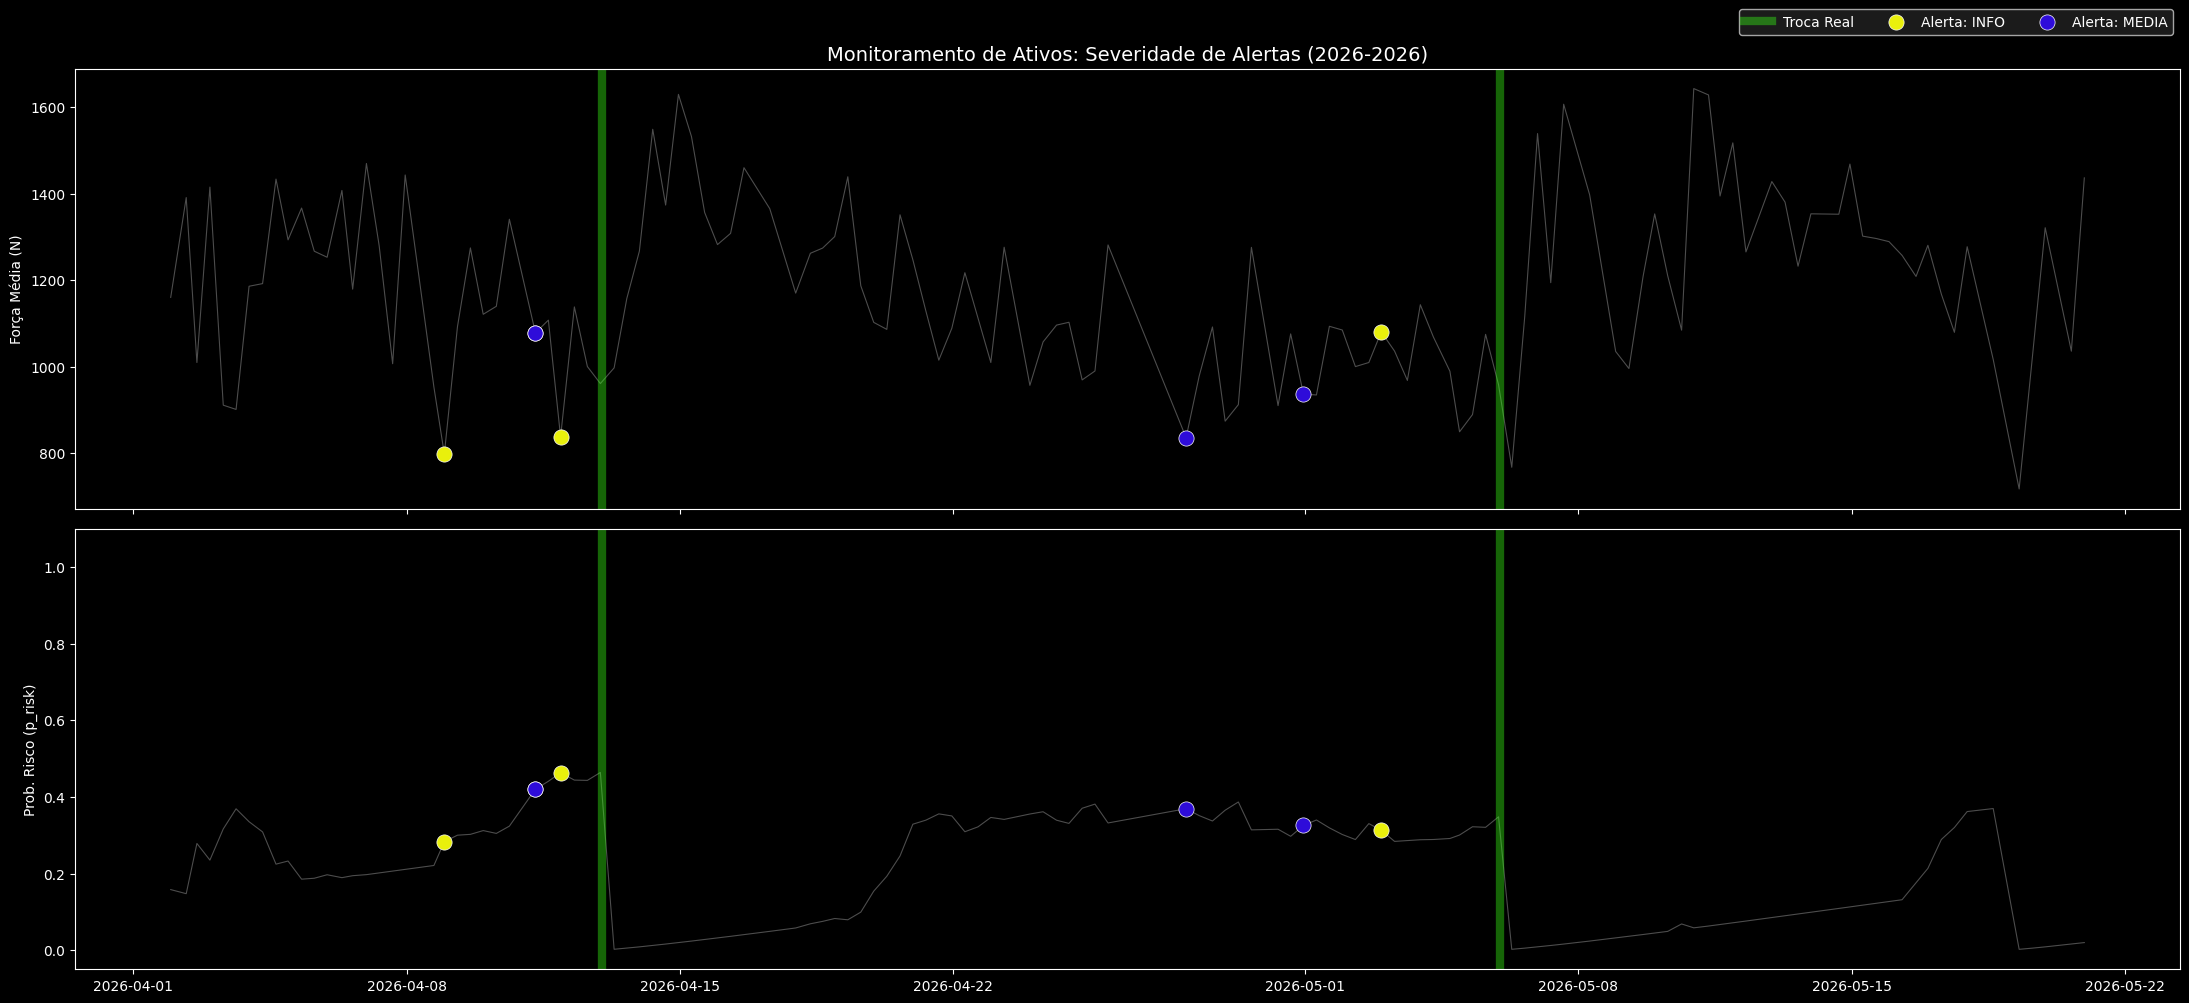

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def force_utc(t):
    ts = pd.to_datetime(t)
    return ts.tz_localize('UTC') if ts.tz is None else ts.tz_convert('UTC')

# 1. Limites e Preparação
inicio = force_utc('2026-04-01')
fim_original = force_utc('2026-12-31 23:59:59')

# --- Nova Lógica: Expansão até o fim do ano atual da variável ---
ano_atual = fim_original.year
fim = force_utc(f'{ano_atual}-12-31 23:59:59')

# Garantir que o índice do DataFrame seja UTC antes de filtrar
if df.index.tz is None:
    df.index = df.index.tz_localize('UTC')
else:
    df.index = df.index.tz_convert('UTC')

df_filt = df.loc[inicio:fim].copy()

# Filtragem das tabelas de eventos e datas de troca
eventos_df['data_disparo'] = eventos_df['data_disparo'].apply(force_utc)
eventos_filt = eventos_df[(eventos_df['data_disparo'] >= inicio) & (eventos_df['data_disparo'] <= fim)].copy()
troca_dates_filt = [t for t in troca_dates if inicio <= force_utc(t) <= fim]

# 2. Configuração de Cores das Severidades
mapa_cores = {
    'INFO': "#e9f00c",     # Amarelo Neon
    'MEDIA': "#2e0cd9",    # Azul Escuro / Neon
    'CRITICA': "#ff0000"   # Vermelho
}
cor_troca = '#39ff14'      # Verde Limão (Barras)

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(22, 10), sharex=True, facecolor='black')

# --- Loop de Plotagem para os dois painéis ---
for i, painel in enumerate(['Media', 'p_risk']):
    ax = axes[i]
    ax.set_facecolor('black')
    
    # Linha base dos dados
    ax.plot(df_filt.index, df_filt[painel], lw=0.8, color='white', alpha=0.3)
    
    # Barras de Troca Real (Verde)
    for j, t in enumerate(troca_dates_filt):
        t_utc = force_utc(t)
        ax.axvline(t_utc, color=cor_troca, lw=6, alpha=0.4, label='Troca Real' if (i==0 and j==0) else "")

    # Pontos de Disparo por Severidade
    if not eventos_filt.empty:
        for sev, grupo in eventos_filt.groupby('severidade'):
            cor = mapa_cores.get(sev, 'white')
            
            # Encontrar pontos no eixo X e Y correspondentes via índice mais próximo
            indices = df_filt.index.get_indexer(grupo['data_disparo'], method='nearest')
            x_pts = df_filt.index[indices]
            y_pts = df_filt.iloc[indices][painel]
            
            ax.scatter(x_pts, y_pts, color=cor, s=120, zorder=10, 
                       edgecolors='white', lw=0.5, label=f'Alerta: {sev}' if i == 0 else "")

# Ajustes Finais do Gráfico
axes[0].set_title(f'Monitoramento de Ativos: Severidade de Alertas ({inicio.year}-{ano_atual})', fontsize=14)
axes[0].set_ylabel('Força Média (N)')
axes[1].set_ylabel('Prob. Risco (p_risk)')
axes[1].set_ylim(-0.05, 1.1)

# Legenda unificada no topo
axes[0].legend(loc='upper right', bbox_to_anchor=(1, 1.15), ncol=5, frameon=True, facecolor='#222')

plt.tight_layout()
plt.show()


## Etapa D — Estado atual

In [9]:
from src.trigger_engine import compute_p_risk_snapshot

ultima_troca = troca_dates[-1]
hoje = df.index.max().normalize()

state_atual = Path('state_fb14.json')
engine_atual = TriggerEngine(MAQUINA, state_atual)

df_atual = df[df.index >= ultima_troca]

print(f'Ultima troca : {ultima_troca.date()}')
print(f'Avaliando em : {hoje.date()}')
print(f'Dados no ciclo atual : {len(df_atual)} linhas')
print()

if df_atual.empty:
    print('Ciclo atual sem dados — nao e possivel avaliar.')
else:
    snap = compute_p_risk_snapshot(df, ultima_troca.to_pydatetime(), hoje)
    print('── Snapshot p_risk (engine v2) ─────────────────────────')
    for k, v in snap.items():
        flag = ''
        if k == 'cond_p_risk' and v:  flag = '  ✓ COND1'
        if k == 'cond_signal'  and v:  flag = '  ✓ COND2'
        if k == 'cond_idade'   and v:  flag = '  ✓ COND3'
        if k == 'cond_proj'    and v:  flag = '  ✓ COND4'
        print(f'  {k:<15}: {v}{flag}')
    print()

    eventos_hoje = engine_atual.evaluate(
        df,
        troca_date=ultima_troca.to_pydatetime(),
        sp_client=None,
        today=hoje,
    )

    if eventos_hoje:
        print(f'  GATILHO RED DISPARADO ({len(eventos_hoje)}):')
        for ev in eventos_hoje:
            print(f'    p_risk={ev.score_atual:.3f}  signal={ev.signal_score:.3f}  proj48h={ev.proj_48h:.0f}N')
            print(f'    Mensagem: {ev.mensagem}')
    else:
        print('  Nenhum gatilho RED disparado hoje — situacao NORMAL.')

    print()
    print('Estado do engine (state_fb14.json):')
    with open(state_atual) as f:
        print(json.dumps(json.load(f), indent=2))


Ultima troca : 2026-05-06
Avaliando em : 2026-05-20
Dados no ciclo atual : 38 linhas

── Snapshot p_risk (engine v2) ─────────────────────────
  today          : 2026-05-20
  age_days       : 14
  mean_3d        : 1085.3
  mean_14d       : 1261.1
  min_3d         : 717.0
  mediana_3d     : 1079.3
  n_leituras_abaixo_800: 1
  ratio_3_14     : 0.8606
  slope_7d       : -55.0
  proj_48h       : 975.3
  age_risk       : 0.1836
  sig_score      : 0.4837
  p_risk         : 0.4403
  cond_p_risk    : False
  cond_signal    : True  ✓ COND2
  cond_idade     : False
  cond_proj      : False
  cond_emerg     : True
  cond_outlier_sinal: True

  Nenhum gatilho RED disparado hoje — situacao NORMAL.

Estado do engine (state_fb14.json):
{
  "maquina": "FB14",
  "red": {
    "red_sp_id": null,
    "last_fired": null,
    "snooze_until": null,
    "proj_window": [
      {
        "date": "2026-05-20",
        "proj": 903.3
      },
      {
        "date": "2026-05-20",
        "proj": 975.3
      },
   

## Etapa E — Escrever no SharePoint (opcional)

Executar somente quando `ESCREVER_SP = True` na célula de configuração.  
Requer `sharepoint.ev` com `SP_USER=` e `SP_PASS=`.

if not ESCREVER_SP:
    print('ESCREVER_SP=False -- pulando escrita no SharePoint.')
    print('Para ativar: set ESCREVER_SP = True na celula de configuracao.')
else:
    from src.sharepoint_methods import SharePointClient
    from dotenv import dotenv_values

    creds = dotenv_values('../sharepoint.ev')
    sp_user = creds.get('SP_USER')
    sp_pass = creds.get('SP_PASS')
    sp_url  = creds.get('SP_URL', 'https://kimberlyclark.sharepoint.com/Sites/H945')

    if not sp_user or not sp_pass:
        raise RuntimeError('Credenciais SP_USER/SP_PASS nao encontradas em sharepoint.ev')

    sp_client = SharePointClient(url=sp_url, username=sp_user, password=sp_pass)

    engine_sp = TriggerEngine(MAQUINA, Path('state_fb14.json'))
    eventos_sp = engine_sp.evaluate(
        df,
        troca_date=ultima_troca.to_pydatetime(),
        sp_client=sp_client,
        list_name=LIST_NAME,
        today=hoje,
    )

    if eventos_sp:
        print(f'{len(eventos_sp)} evento(s) escrito(s) na lista "{LIST_NAME}":')
        for ev in eventos_sp:
            print(f'  [{ev.severidade}] {ev.gatilho}  SP_ID={ev.sp_item_id}')
    else:
        print('Nenhum evento para escrever -- estado atual normal.')

## Resumo do backtest

In [ ]:
if not eventos_df.empty:
    print('=' * 60)
    print('  RESUMO DO BACKTEST v2 — Gatilho RED')
    print('=' * 60)
    n_ciclos = len(troca_dates) - 1
    cobertos = eventos_df['ciclo_id'].nunique()
    print(f'  Ciclos historicos avaliados : {n_ciclos}')
    print(f'  Total de disparos RED       : {len(eventos_df)}')
    print(f'  Ciclos com disparo          : {cobertos} / {n_ciclos}  ({cobertos/n_ciclos:.0%})')
    print()

    ant = eventos_df.sort_values('antecedencia_d', ascending=False)                     .groupby('ciclo_id', as_index=False).first()
    vals_ant = ant['antecedencia_d']
    vals_p   = ant['p_risk']
    print(f'  Antecedencia do 1o disparo RED:')
    print(f'    median = {vals_ant.median():.0f} dias')
    print(f'    min    = {vals_ant.min():.0f} dias')
    print(f'    max    = {vals_ant.max():.0f} dias')
    print()
    print(f'  p_risk no 1o disparo por ciclo:')
    print(f'    median = {vals_p.median():.3f}')
    print(f'    min    = {vals_p.min():.3f}')
    print(f'    max    = {vals_p.max():.3f}')
    print()

    # Ciclos silenciosos (sem disparo)
    todos_ciclos = set(range(len(troca_dates) - 1))
    ciclos_fire  = set(eventos_df['ciclo_id'].unique())
    ciclos_sil   = sorted(todos_ciclos - ciclos_fire)
    if ciclos_sil:
        print(f'  Ciclos silenciosos (sem RED): {ciclos_sil}')
        print('  (ciclos curtos = trocas preventivas — comportamento esperado)')
    print('=' * 60)
else:
    print('Nenhum evento RED disparado no backtest.')


## Etapa F — Envio retroativo: backtest 2026 → SharePoint

Envia todos os eventos de `eventos_filt` (2026) para a lista `Gatilhos_Selagem`,
gerando o `TeamsPayload` (Adaptive Card) para cada alerta.

Pré-requisito: `sharepoint.ev` com `SP_USER=` e `SP_PASS=` na raiz do projeto.

In [ ]:
eventos_filt['data_disparo'] = pd.to_datetime(eventos_filt['data_disparo'])

eventos_filt = eventos_filt[
    (eventos_filt['data_disparo'].dt.year == 2026) &
    (eventos_filt['data_disparo'].dt.month >= 4)
]

eventos_filt = eventos_filt.sort_values(by='data_disparo', ascending=True)
eventos_filt

In [ ]:
from dotenv import dotenv_values
from src.sharepoint_methods import SharePointClient
from src.card_formatter import build_alert_card
import numpy as np

# ── Conexão SharePoint — credenciais e URL lidas de sharepoint.ev ────────────
creds     = dotenv_values('../sharepoint.ev')
SP_URL    = creds.get('SP_URL', '')
LIST_NAME = 'Gatilhos_Selagem'
BATCH_SIZE = 10

_ACAO = {
    'RED':        ('Programar inspeção preventiva do rolo maintacker. '
                   'Verificar força de selagem no próximo turno. '
                   'Registrar: OK / Troca programada / Troca imediata.'),
    'AMARELO':    ('Monitorar força de selagem diariamente. '
                   'Incluir troca do maintacker no próximo plano de manutenção preventiva.'),
    'EMERGENCIA': ('AÇÃO IMEDIATA: verificar força de selagem no próximo turno. '
                   'Se força < 800 N, trocar o rolo maintacker. '
                   'Inspecionar regulagem de pressão e desgaste do rolo.'),
    'REVISAO':    ('Revisar tendência de força no gráfico. '
                   'Se forças abaixo de 900 N ou tendência negativa persistente, '
                   'antecipar inspeção do rolo.'),
}

def _nan_to_none(x):
    if x is None:
        return None
    try:
        return None if np.isnan(float(x)) else float(x)
    except (TypeError, ValueError):
        return None

sp = SharePointClient("https://kimberlyclark.sharepoint.com/Sites/H945", creds['SP_USER'], creds['SP_PASS'])
print('SharePoint conectado.')

# ── Títulos já existentes na lista (deduplicação) ───────────────────────────
df_existentes = sp.query_large_list(LIST_NAME)
titles_existentes = set(df_existentes['Title'].dropna()) if 'Title' in df_existentes.columns else set()
print(f'Itens já na lista     : {len(titles_existentes)}')
print(f'Eventos 2026 no backtest: {len(eventos_filt)}')

# ── Monta itens novos (ignora os que já existem) ────────────────────────────
itens = []
pulados = []
for _, ev in eventos_filt.iterrows():
    gatilho = ev['gatilho']
    data_ts = ev['data_disparo']
    title   = f"{MAQUINA} | {gatilho} | {data_ts.strftime('%Y-%m-%d')}"

    if title in titles_existentes:
        pulados.append(title)
        continue

    payload = build_alert_card(
        maquina          = MAQUINA,
        gatilho          = gatilho,
        idade_dias       = int(ev['idade_dias']),
        p_risk           = float(ev['p_risk']),
        slope_7d         = _nan_to_none(ev['slope_7d']),
        forca_min_3d     = _nan_to_none(ev['mean_3d']),
        proj_48h         = _nan_to_none(ev['proj_48h']),
        acao_recomendada = _ACAO.get(gatilho, 'Avaliar situação com equipe de manutenção.'),
        data_disparo     = data_ts.to_pydatetime(),
    )
    itens.append({'Title': title, 'Maquina': MAQUINA, 'TeamsPayload': payload})

print(f'Já existentes (pulados): {len(pulados)}')
print(f'Novos a inserir        : {len(itens)}')
print()

if not itens:
    print('Nenhum item novo — lista já está atualizada.')
else:
    ids_criados = []
    for i in range(0, len(itens), BATCH_SIZE):
        lote  = itens[i : i + BATCH_SIZE]
        ids   = sp.insert_list_item(LIST_NAME, lote)
        ids_criados.extend(ids)
        datas = [item['Title'].split(' | ')[-1] for item in lote]
        print(f'  Lote {i // BATCH_SIZE + 1:02d}: {len(lote)} itens  '
              f'({datas[0]} → {datas[-1]})  IDs: {ids}')

    print()
    print(f'✓ Total inserido: {len([x for x in ids_criados if x])} / {len(itens)} eventos novos')